*KTH EECS* <br>
*DD2435/FDD3435, Mathematical modelling of biological systems* <br>
<del>*DD2436, Modellering av cellbiologiska processer* </del>

<div align="center">

# Computational Biochemistry
## *Laboratory 2*

</div>

## 1 Create a model of an enzyme

You will in this laboration model a part of one really ancient biochemical pathway: the glycolysis, which is of greatest importance for living cells and converts glucose to pyruvate, which is then further degraded, yielding ATP, which has a high $\Delta_f G^\circ$ and is ubiquitous as a coupled reactant in energy-demanding reactions. In the first exercise you will model one of the enzymes in the pathway, phosphofructokinase (PFK), which catalyses the reaction from fructose-6-phosphate (F6P) to fructose-1,6-bisphosphate (FBP), while consuming ATP and yielding ADP. This reaction has a $\Delta G^\circ$ of about $-3.5$ kcal/mol. This means that we can approximate the reaction as being irreversible.

**Tasks and questions:**

* Why is that? Calculate the equilibrium constant of the reaction. 1 kcal $= 4.1868$ kJ, $R = 8.314$ J/mol K (molar gas constant). Both ATP and F6P are generally present in greater concentrations in the cell than ADP and FBP, respectively.
> At the examination of the lab, tasks and questions marked with a bullet point (•) should be presented and answered respectively.

**Convert ΔG° from kcal/mol to J/mol**

$$\Delta G^\circ = -3.5\ \text{kcal/mol} \times 4.1868\ \frac{\text{kJ}}{\text{kcal}} = -14.65\ \text{kJ/mol} = -14653.8\ \text{J/mol}$$

**Relate ΔG° to the equilibrium constant**

$$\Delta G^\circ = -RT\ln K'$$

Solving for $K'$ (assuming standard temperature $T = 298\ \text{K}$):

$$\ln K' = -\frac{\Delta G^\circ}{RT} = -\frac{-14653.8\ \text{J/mol}}{8.314\ \text{J} \cdot \text{mol}^{-1} \cdot \text{K}^{-1} \times 298\ \text{K}} = \frac{14653.8}{2477.6} \approx 5.915$$

$$K' = e^{5.915} \approx 371$$

**Interpretation**

Since $K' = \dfrac{[\text{FBP}][\text{ADP}]}{[\text{F6P}][\text{ATP}]} \approx 371 \gg 1$, the reaction strongly favors the products (FBP + ADP) at equilibrium. Combined with the fact that **ATP and F6P are kept at much higher concentrations than ADP and FBP** in the cell, the mass-action ratio $\Gamma = \dfrac{[\text{FBP}][\text{ADP}]}{[\text{F6P}][\text{ATP}]}$ stays far below $K'$ under physiological conditions. This means the reverse reaction term $\left(1 - \dfrac{\Gamma}{K'}\right)$ stays close to 1, so the backward flux is negligible and the reaction can safely be treated as **irreversible**.

As noted above, the enzyme has ATP and ADP as substrate and product respectively, but we'll ignore this and assume these species as being constant! Please use equation (33) in part 1 of the study notes. 

<div style="background-color: #f4f4f4; padding: 16px; border-radius: 6px; border: 1px solid #e0e0e0;">

$$\frac{j_{tot}}{V_{f}}=\frac{\sigma\left(1-\frac{\Gamma}{K^{\prime}}\right)(\sigma+\pi)^{n-1}}{(\sigma+\pi)^{n}+\frac{1+\xi^{n}}{1+\alpha\xi^{n}}} ,$$

where $j_{tot}$ is the net overall reaction flux, $V_f$ is the maximum forward reaction velocity, $\sigma$ is the normalized substrate concentration, $\Gamma$ is the mass action ratio, $K'$ is the equilibrium constant of the reaction, $\pi$ is the normalized product concentration, $n$ is the Hill coefficient, representing the degree of cooperativity or number of binding sites, $\xi$ is the normalized modulator concentration, $\alpha$ is a parameter inversely related to the factor by which modulator alters the substrate's affinity for the enzyme:
<div style="padding-left: 2rem;">
if $0 \le \alpha < 1$, the concentration of the modulator species $X$ acts as an inhibitor,<br>
if $\alpha > 1$, $X$ acts as an activator,<br>
if $\alpha = 1$, $X$ has no effect on enzyme activity.
</div>
</div>

Note that since we assume that the reaction is irreversible, you do not need to include the terms that have to do with backward flow from product to substrate. This means that the $\pi$ and $\Gamma / K'$ terms can be neglected (just pretend that they equal zero). However, the $\xi$ term should not be neglected -- this term has to do with the modulation of the enzyme in the forward (substrate to product) reaction!

Here are the facts you need to know:

1. The enzyme is half activated when F6P is about 8 mM and no FBP is present.

2. The enzyme is activated by its product, FBP, which binds to the enzyme with a dissociation constant of $3\,\mu M$.

3. When adding excess FBP, the enzyme is half activated at only 0.8 mM F6P!

   > *Hint:* let the modifier concentration approach infinity. Then solve equation (33) for $\alpha$ assuming that the enzyme is half activated at 0.8 mM F6P. Remember to neglect the $\pi$ and $\Gamma / K'$ parameters in the equation since we assume that the reaction is irreversible.<br> If $\dfrac{j_{tot}}{V_f}$ equals $\dfrac{1}{2}$ then $\dfrac{1+\xi^n}{1+\alpha \xi^n}$ equals what?

**Simplify equation (33) for the irreversible case**

Setting $\pi = 0$ and $\Gamma/K' = 0$, equation (33) reduces to:

$$\frac{j_{tot}}{V_f} = \frac{\sigma^n}{\sigma^n + \dfrac{1+\xi^n}{1+\alpha\xi^n}}$$

**Isolate the ratio using half-activation**

Setting $\dfrac{j_{tot}}{V_f} = \dfrac{1}{2}$:

$$\frac{\sigma^n}{\sigma^n + \dfrac{1+\xi^n}{1+\alpha\xi^n}} = \frac{1}{2}$$

Cross-multiplying:

$$2\sigma^n = \sigma^n + \frac{1+\xi^n}{1+\alpha\xi^n}$$

$$\boxed{\frac{1+\xi^n}{1+\alpha\xi^n} = \sigma^n}$$

**Apply the excess-FBP condition**

Under excess FBP, $\xi \to \infty$, so:

$$\frac{1+\xi^n}{1+\alpha\xi^n} \longrightarrow \frac{1}{\alpha}$$

Combining with the boxed result:

$$\frac{1}{\alpha} = \sigma^n$$

**Evaluate σ at the given half-activation point**

Half-activation under excess FBP occurs at F6P $= 0.8\ \text{mM}$. Since $K_m = 8\ \text{mM}$ :

$$\sigma = \frac{S}{K_m} = \frac{0.8\ \text{mM}}{8\ \text{mM}} = 0.1$$

**Solve for α**

$$\alpha = \frac{1}{\sigma^n} = \frac{1}{(0.1)^n}$$

With the Hill coefficient $n = 2.5$:

$$\alpha = \frac{1}{(0.1)^{2.5}} = 10^{2.5} \approx 316.2$$

Since $\alpha \gg 1$, FBP indeed acts as an **activator** of the enzyme, consistent with fact 2.

5. The enzyme exhibits a sigmoid (s-shaped) concentration-activity curve, with a Hill coefficient of 2.5.

6. The limiting rate is about $100\,\mu\text{mol} \cdot g_{dw}^{-1} \cdot \text{min}^{-1}$, where $g_{dw}$ stands for gram dry weight of living tissue, that is with all water removed. Let's convert this to the standard chemical unit $M \cdot s^{-1}$. Since the rate per second must be $\frac{1}{60}$ of the rate per minute, we can first write the rate as $100 \cdot 10^{-6}\,\text{mol} \cdot g_{dw}^{-1} \cdot \frac{1}{60}\,s^{-1}$. Since M is mole per liter, we now have to convert the $g_{dw}$ term to liters. For this we will use the fact that water constitutes about 75% of a living cell. This means that the dry weight constitutes the remainder, about 25%, so one gram of dry weight corresponds to three grams of water, which (using that the density of water is about $1\,g/cm^3$) is approximately $3\,cm^3$ or $3 \cdot 10^{-3}$ l. Thus, our expression for the limiting rate becomes
$$\frac{100 \cdot 10^{-6}}{60 \cdot 3 \cdot 10^{-3}}\,\text{mol} \cdot l^{-1} s^{-1} = \frac{100}{180 \cdot 10^3}\, M \cdot s^{-1}$$
This value can now be plugged in at the appropriate place in the equation!

**Tasks and questions:**

- Study equation (33) and find out how to use the above information to infer the parameters in the equation.
- Implement the equation as a python function, which takes F6P concentration as input parameter and returns the reaction rate $j$.
- Plot the concentration-activity profile for the enzyme, for some different concentrations of FBP (including large excess) and make sure that the model behaves as is described above.

To help you when getting started with the task described above, a simplified example function is provided and has been implemented according to equation (25) of part 1 of the study notes. 

<div style="background-color: #f4f4f4; padding: 16px; border-radius: 6px; border: 1px solid #e0e0e0;">

$$\frac{j}{V}=\frac{\sigma}{\sigma+1} ,$$

where $j$ is the enzyme-catalyzed reaction, $V$ is the maximum reaction velocity, $\sigma$ is the normalized substrate concentration.
</div>

This reduced case does not take reversibility and cooperativity into consideration and thus items 2-4 above were not addressed. Also, $V_f$ has been set to 1.

Example Python code for the function computing $j$ is shown below.

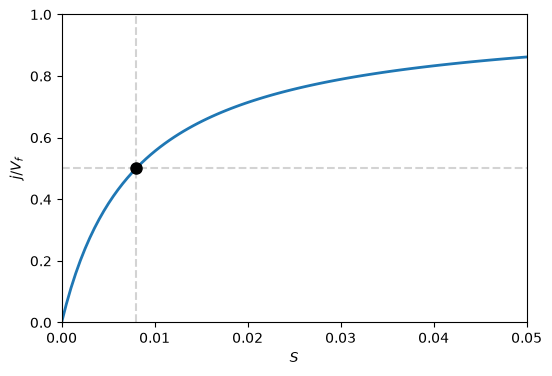

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Vf = 1.0

def func(S, X):
    global Vf
    Km = 8e-3
    sigma = S / Km
    Vf = 1.0
    j = Vf * sigma / (1 + sigma)
    return j

# parameters
Km = 8e-3
Vf = 1.0

# define substrate range S in [0, 0.05]
S = np.linspace(0, 0.05, 100)

# calculate j / Vf ratio
sigma = S / Km
j_over_Vf = sigma / (1 + sigma)

# coordinates for j/Vf = 0.5 point (S = Km)
S_target = Km
j_target = 0.5

# plot
plt.figure(figsize=(6, 4))
plt.plot(S, j_over_Vf, color='tab:blue', linewidth=2)
plt.plot(S_target, j_target, 'ko', markersize=8)
plt.axvline(x=S_target, color='lightgrey', linestyle='--', zorder=1)
plt.axhline(y=j_target, color='lightgrey', linestyle='--', zorder=1)
plt.xlabel('$S$')
plt.ylabel(r'$j / V_f$')
plt.xlim(0, 0.05)
plt.ylim(0, 1.0);

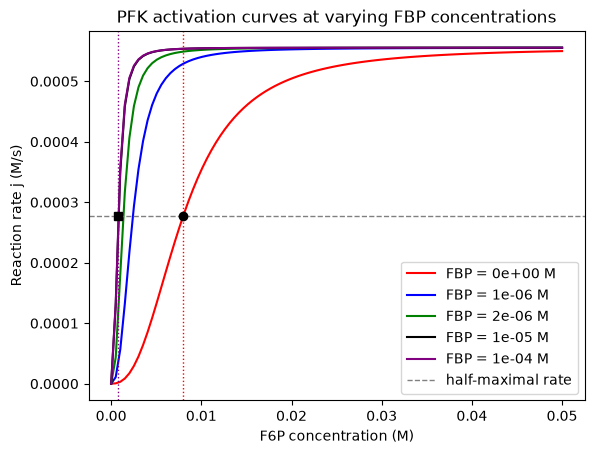

In [2]:
# the code here
#
#

import numpy as np
import matplotlib.pyplot as plt

# irreversible case:
pi = 0
gamma_over_K = 0

# parameters:
Km = 8e-3 #M
n = 2.5
Kx = 3e-6 #M
alpha = np.power(10,2.5)
Vf = 100 / (180e3) #M/s

def j(F6P, FBP):
    sigma = F6P / Km
    xi = FBP / Kx
    sigma_n = np.power(sigma, n)
    denominator_frac = (1+xi**n)/(1+alpha*(xi**n))
    fraction = sigma_n / (sigma_n + denominator_frac)
    return Vf * fraction

F6P_list = np.linspace(0, 0.05, 100)
FBP_list = [0.0, 1e-6, 2e-6, 1e-5, 1e-4]
color_list = ["red", "blue", "green", "black", "purple"]

plt.figure()
for FBP, color in zip(FBP_list, color_list):
    j_list = []
    for F6P in F6P_list:
        j_list.append(j(F6P, FBP))
    plt.plot(F6P_list, j_list, color = color, label= f"FBP = {FBP:.0e} M")

plt.axhline(y=Vf/2, color='grey', linestyle='--', linewidth=1, label='half-maximal rate')
plt.axvline(x=Km, color='red', linestyle=':', linewidth=1)      # 8 mM, no-FBP case
plt.axvline(x=0.8e-3, color='purple', linestyle=':', linewidth=1)  # 0.8 mM, excess-FBP case
plt.plot(Km, Vf/2, 'ko', markersize=6)        # expect FBP=0 curve to pass through here
plt.plot(0.8e-3, Vf/2, 'ks', markersize=6)    # expect excess-FBP curve to pass through here
plt.legend()
plt.xlabel("F6P concentration (M)")
plt.ylabel("Reaction rate j (M/s)")
plt.title("PFK activation curves at varying FBP concentrations")
plt.show()

## 2 Watch the enzyme in action

Now it's time to see how this enzyme behaves when given an influx and an enzyme catalysed efflux. Assume that F6P is created with an influx of $0.6\,\mu M \cdot s^{-1}$. Also, FBP is removed through the enzyme catalysed reaction where FBP is split into dihydroxyacetone phosphate (DHAP) and glyceraldehyde-3-phosphate (GAP). This is catalysed by the enzyme aldolase. Assume that this reaction is irreversible, too (our little model won't include DHAP and GAP), and has a limiting rate of $60\,\mu M \cdot s^{-1}$. Aldolase operates with a hyperbolic concentration-activity curve (the Hill coefficient is equal to one) and has a Michaelis constant towards FBP of about $10\,\mu M$. Start out from equation (1) in part 2 of the study notes and design and perform a simulation of the system!

<div style="background-color: #f4f4f4; padding: 16px; border-radius: 6px; border: 1px solid #e0e0e0;">

$$\frac{dS}{dt} = Nj ,$$

where $S$ is the vector of state concentrations ($m \times 1$), representing the concentrations of all $m$ chemical species or metabolites in the network, $t$ is time variable, $\frac{dS}{dt}$ is the time derivative vector ($m \times 1$), representing the net rate of change of species concentrations over time, $N$ is the stoichiometry matrix of size $m \times n$, where $m$ is the total number of chemical species and $n$ is the total number of reactions, $j$ is the reaction rate vector (or flux vector) of dimension $n \times 1$, containing the rate/flux of each reaction in the network.
</div>

**Tasks and questions:**

- Start with the stoichiometry matrix and then implement the reaction fluxes. Write a function that computes the concentration derivatives.

- Then solve the small system of differential equations numerically.

It's convenient to use Python's `scipy.integrate.solve_ivp` function for this purpose. The syntax is

> ```python
> from scipy.integrate import solve_ivp
> 
> sol = solve_ivp(functionname, [0, finish], bv, method='BDF', atol=1e-12, rtol=1e-9)
> ```

where `functionname` refers to a function that in your case implements the system described as equation (1) in part 2 of the study notes, `finish` stands for the time in seconds when you abort the simulation and `method='BDF'` (or `'Radau'`) is used since these are stiff-solver methods, analogous to MATLAB's `ode15s`.

In [3]:
# the code here
#
#
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- ICI : la fonction j_PFK de la partie 1, fournie par votre camarade ---
# def j_PFK(S, X):
#     ...
#     return j

# ---------------------------------------------------------------------------
# Flux de l'aldolase : Michaelis-Menten simple (Hill = 1), irréversible
# ---------------------------------------------------------------------------
Vf_ald = 60e-6      # M/s  (60 µM/s)
Km_ald = 10e-6       # M   (10 µM)
N = np.array([[ 1, -1,  0],
              [ 0,  1, -1]])

def j_ald(FBP):
    return Vf_ald * FBP / (Km_ald + FBP)

# ---------------------------------------------------------------------------
# Fonction des dérivées (à passer à solve_ivp)
# ---------------------------------------------------------------------------

def rhs(t, y, v_in):
    F6P, FBP = y
    F6P = max(F6P, 0.0)   # évite les petits dépassements négatifs du solveur
    FBP = max(FBP, 0.0)

    v = np.array([
        v_in,                 # influx constant de F6P
        j(F6P, FBP),       # PFK : F6P -> FBP
        j_ald(FBP)             # aldolase : FBP -> produits
    ])

    dy_dt = N @ v
    return dy_dt   # tableau 1D de taille 2

# ---------------------------------------------------------------------------
# Simulation
# ---------------------------------------------------------------------------
def run_simulation(v_in, t_end=2000):
    bv = [1e-3, 1e-6]   # conditions initiales : F6P = 1 mM, FBP = 1 µM
    sol = solve_ivp(rhs, [0, t_end], bv, args=(v_in,),
                     method='BDF', atol=1e-12, rtol=1e-9)
    return sol

Finally, `bv` is a vector of initial values; you can use F6P $= 1$ mM, FBP $= 1\,\mu M$. The solution will appear in `sol.t` (vector of time points) and `sol.y` (matrix of solution points, with each row representing one variable -- note that `solve_ivp`'s `y` array is transposed, with each row corresponding to one variable and each column corresponding to a time point). You have two variables in your system. Run the simulations at least 2000 seconds. Note that your function `functionname` must return a column vector (in Python, a 1-D array/list of the derivatives). Type `help(solve_ivp)` for further information.

**Tasks and questions:**

- Plot the concentration of F6P and FBP versus time. What does the behaviour mean thermodynamically?

- Increase the influx to $6\,\mu M \cdot s^{-1}$. Again, plot the concentration of F6P and FBP versus time. You should observe quite a different behaviour. What do you think this mean thermodynamically?

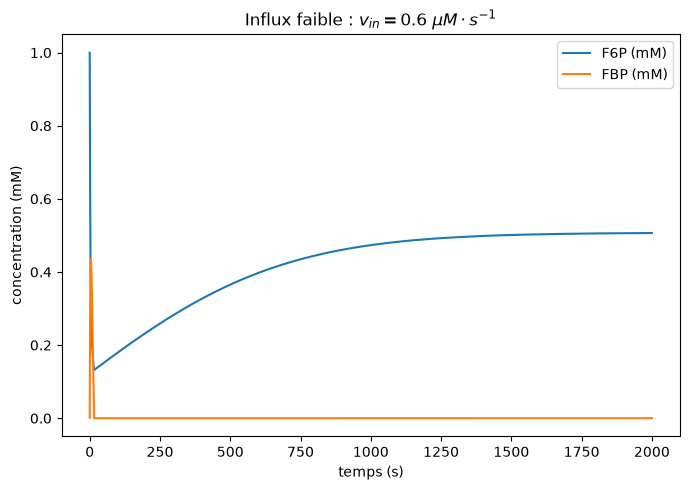

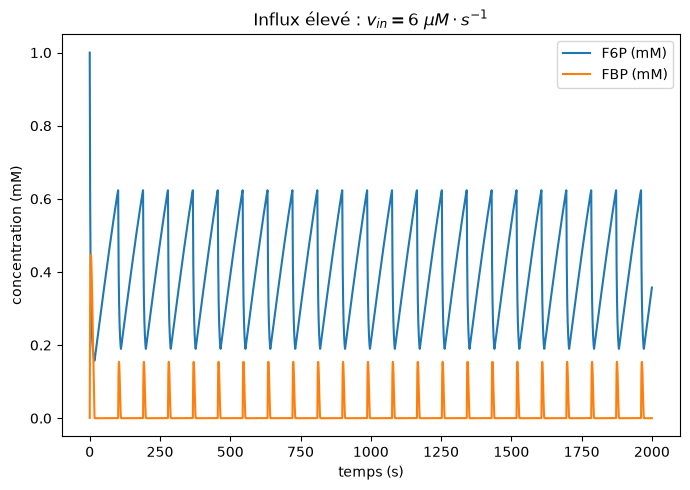

In [4]:
# the code here
#
#

# --- Cas A : influx faible, 0.6 µM/s ---
sol_low = run_simulation(v_in=0.6e-6, t_end=2000)

plt.figure(figsize=(7, 5))
plt.plot(sol_low.t, sol_low.y[0] * 1e3, label='F6P (mM)')
plt.plot(sol_low.t, sol_low.y[1] * 1e3, label='FBP (mM)')
plt.xlabel('temps (s)')
plt.ylabel('concentration (mM)')
plt.title(r'Influx faible : $v_{in} = 0.6\ \mu M\cdot s^{-1}$')
plt.legend()
plt.tight_layout()
plt.show()

# --- Cas B : influx élevé, 6 µM/s ---
sol_high = run_simulation(v_in=6e-6, t_end=2000)

plt.figure(figsize=(7, 5))
plt.plot(sol_high.t, sol_high.y[0] * 1e3, label='F6P (mM)')
plt.plot(sol_high.t, sol_high.y[1] * 1e3, label='FBP (mM)')
plt.xlabel('temps (s)')
plt.ylabel('concentration (mM)')
plt.title(r'Influx élevé : $v_{in} = 6\ \mu M\cdot s^{-1}$')
plt.legend()
plt.tight_layout()
plt.show()

<div align="center">

### Good luck!

</div>